**RandomForest_ENAHO_2024_Binario.ipynb**

*Creado por EMRB | Versión local*

# 0. Condiciones del sistema

In [2]:
import sys, os
print("Python:", sys.version)
print("Directorio de trabajo:", os.getcwd())

Python: 3.12.4 (tags/v3.12.4:8e8a4ba, Jun  6 2024, 19:30:16) [MSC v.1940 64 bit (AMD64)]
Directorio de trabajo: d:\2025\PEU-IENI\CURSO POWER BI\EXAMEN_FINAL\Regresion


In [3]:
import importlib, subprocess, sys

required = {
    "imbalanced-learn": "imblearn",
    "scikit-learn":     "sklearn",
    "pandas":           "pandas",
    "numpy":            "numpy",
    "matplotlib":       "matplotlib",
    "seaborn":          "seaborn",
    "joblib":           "joblib",
}
for pkg, mod in required.items():
    if importlib.util.find_spec(mod) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])
        print(pkg, "instalado.")
    else:
        print(pkg, "ya disponible.")

imbalanced-learn ya disponible.
scikit-learn ya disponible.
pandas ya disponible.
numpy ya disponible.
matplotlib ya disponible.
seaborn ya disponible.
joblib ya disponible.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve,
                              ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
import joblib
import warnings
warnings.filterwarnings("ignore")

# 1. Configuración de rutas (ejecución local)

In [5]:
BASE_DIR   = Path(".").resolve()
DATA_FILE  = BASE_DIR / "sumaria-2024_x.dta"
MODEL_FILE = BASE_DIR / "modelo_rf_enaho_2024_binario.joblib"

print("Carpeta de trabajo :", BASE_DIR)
print("Archivo de datos   :", DATA_FILE)
print("Archivo de modelo  :", MODEL_FILE)

if not DATA_FILE.exists():
    raise FileNotFoundError(
        "No se encontro: " + str(DATA_FILE) +
        " | Coloca sumaria-2024_x.dta en: " + str(BASE_DIR)
    )

Carpeta de trabajo : D:\2025\PEU-IENI\CURSO POWER BI\EXAMEN_FINAL\Regresion
Archivo de datos   : D:\2025\PEU-IENI\CURSO POWER BI\EXAMEN_FINAL\Regresion\sumaria-2024_x.dta
Archivo de modelo  : D:\2025\PEU-IENI\CURSO POWER BI\EXAMEN_FINAL\Regresion\modelo_rf_enaho_2024_binario.joblib


# 2. Cargar datos

In [6]:
df = pd.read_stata(DATA_FILE)
print("Dimensiones originales:", df.shape)
print("Total columnas:", len(df.columns))
print("Columnas:", df.columns.tolist())

Dimensiones originales: (33691, 164)
Total columnas: 164
Columnas: ['aÑo', 'mes', 'conglome', 'vivienda', 'hogar', 'ubigeo', 'dominio', 'estrato', 'mieperho', 'totmieho', 'percepho', 'ia01hd', 'ia02hd', 'ig03hd1', 'ig03hd2', 'ig03hd3', 'ig03hd4', 'ga03hd', 'ga04hd', 'sg23', 'sig24', 'sg25', 'sig26', 'sg27', 'sig28', 'sg42', 'sg421', 'sg422', 'sg423', 'sg42d', 'sg42d1', 'sg42d2', 'sg42d3', 'ingbruhd', 'ingnethd', 'pagesphd', 'ingindhd', 'ingauthd', 'insedthd', 'insedlhd', 'paesechd', 'ingseihd', 'isecauhd', 'ingexthd', 'ingtrahd', 'ingtexhd', 'ingrenhd', 'ingoexhd', 'g05hd', 'ig06hd', 'g05hd1', 'ig06hd1', 'g05hd2', 'ig06hd2', 'g05hd3', 'ig06hd3', 'g05hd4', 'ig06hd4', 'g05hd5', 'ig06hd5', 'g05hd6', 'ig06hd6', 'g07hd', 'ig08hd', 'ingtprhd', 'ingtpuhd', 'ingtpu01', 'ingtpu02', 'ingtpu03', 'ingtpu04', 'ingtpu05', 'ingtpu10', 'ingtpu11', 'ingtpu12', 'ingtpu13', 'ingtpu14', 'ingtpu15', 'ingtpu16', 'gru11hd', 'gru12hd1', 'gru12hd2', 'gru13hd1', 'gru13hd2', 'gru13hd3', 'gru13hd4', 'gru14hd', 'g

# 3. Seleccionar variables

In [7]:
features = ["mieperho", "percepho", "dominio", "estrato", "gru71hd"]
target   = "pobreza2"
weights  = "factor07"

missing_cols = [c for c in features + [target, weights] if c not in df.columns]
if missing_cols:
    raise ValueError("Columnas faltantes: " + str(missing_cols))

data = df[features + [target, weights]].copy()
print("Columnas seleccionadas OK")

Columnas seleccionadas OK


# 4. Limpieza y preparación de la variable objetivo

In [8]:
print("Valores nulos por columna:")
print(data.isnull().sum())
data.dropna(inplace=True)
print("Dimensiones tras eliminar nulos:", data.shape)

print("Distribucion original de pobreza2:")
print(data[target].value_counts())

if data[target].dtype == object or str(data[target].dtype) == "category":
    mapping = {
        v: (0 if "pobre" in str(v).lower() and "no" not in str(v).lower() else 1)
        for v in data[target].unique()
    }
    print("Mapeo aplicado:", mapping)
    data[target] = data[target].map(mapping)

data[target] = data[target].astype(int)
assert set(data[target].unique()).issubset({0, 1})
print("Distribucion final (0=Pobre, 1=No pobre):")
print(data[target].value_counts())

Valores nulos por columna:
mieperho    0
percepho    0
dominio     0
estrato     0
gru71hd     0
pobreza2    0
factor07    0
dtype: int64
Dimensiones tras eliminar nulos: (33691, 7)
Distribucion original de pobreza2:
pobreza2
No pobre    26879
Pobre        6812
Name: count, dtype: int64
Mapeo aplicado: {'No pobre': 1, 'Pobre': 0}
Distribucion final (0=Pobre, 1=No pobre):
pobreza2
1    26879
0     6812
Name: count, dtype: int64


# 5. División entrenamiento / prueba

In [9]:
X = data[features]
y = data[target]
sample_weights = data[weights].values

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, sample_weights,
    test_size=0.2, random_state=123, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Prop. pobres - train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

Train: (26952, 5) | Test: (6739, 5)
Prop. pobres - train: 0.798 | test: 0.798


# 6. Pipeline de preprocesamiento y modelo

In [10]:
categorical_features = ["dominio", "estrato"]
numeric_features     = ["mieperho", "percepho", "gru71hd"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(),                           numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore",
                         sparse_output=False),         categorical_features),
])

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(class_weight="balanced", random_state=123)),
])

print("Pipeline creado correctamente.")

Pipeline creado correctamente.


# 7. Búsqueda de hiperparámetros (GridSearchCV)

In [11]:
param_grid = {
    "classifier__n_estimators":      [100, 200],
    "classifier__max_depth":         [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf":  [1, 2],
    "classifier__max_features":      ["sqrt", "log2"],
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=123)

grid_search = GridSearchCV(
    rf_pipe, param_grid, cv=cv,
    scoring="roc_auc", n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train, classifier__sample_weight=w_train)

print("Mejores hiperparametros:", grid_search.best_params_)
print("Mejor AUC-ROC en CV:", round(grid_search.best_score_, 4))
best_model = grid_search.best_estimator_

Fitting 10 folds for each of 48 candidates, totalling 480 fits
Mejores hiperparametros: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Mejor AUC-ROC en CV: 0.8277


# 8. Evaluación en conjunto de prueba

Exactitud : 0.717
AUC-ROC   : 0.8266
Reporte de clasificacion:
              precision    recall  f1-score   support

       Pobre       0.40      0.78      0.53      1363
    No pobre       0.93      0.70      0.80      5376

    accuracy                           0.72      6739
   macro avg       0.66      0.74      0.66      6739
weighted avg       0.82      0.72      0.74      6739



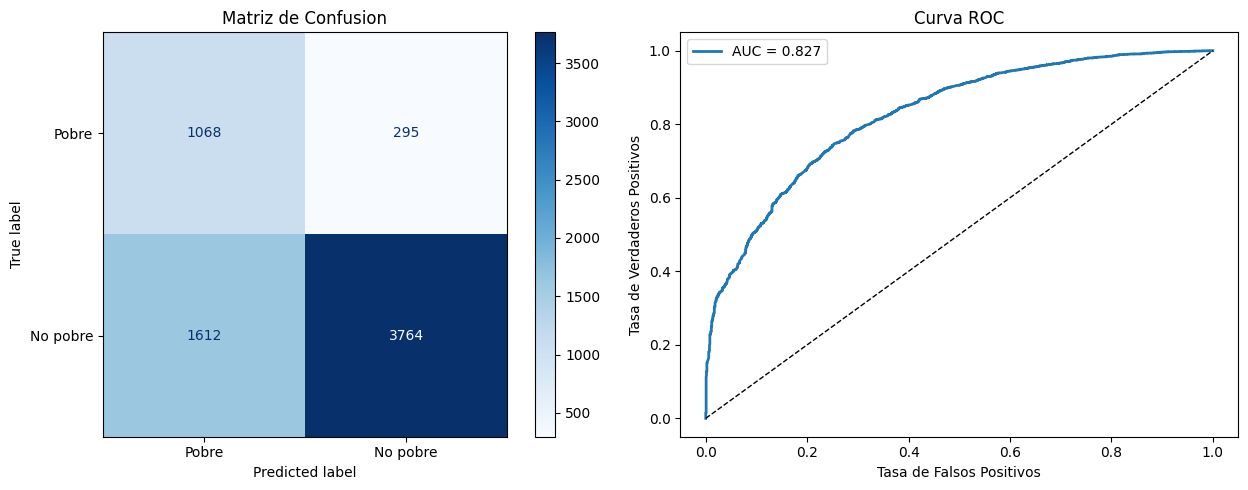

In [12]:
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Exactitud :", round(acc, 4))
print("AUC-ROC   :", round(auc, 4))
print("Reporte de clasificacion:")
print(classification_report(y_test, y_pred, target_names=["Pobre", "No pobre"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Pobre", "No pobre"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Matriz de Confusion")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, label="AUC = " + str(round(auc, 3)))
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_xlabel("Tasa de Falsos Positivos")
axes[1].set_ylabel("Tasa de Verdaderos Positivos")
axes[1].set_title("Curva ROC")
axes[1].legend()
plt.tight_layout()
plt.show()

# 9. Importancia de variables (permutación)

Importancia de variables (disminucion de AUC-ROC):
 feature  importance_mean  importance_std
mieperho         0.200564        0.005676
 gru71hd         0.165885        0.008497
 dominio         0.029503        0.002246
 estrato         0.026521        0.002953
percepho         0.011311        0.001575


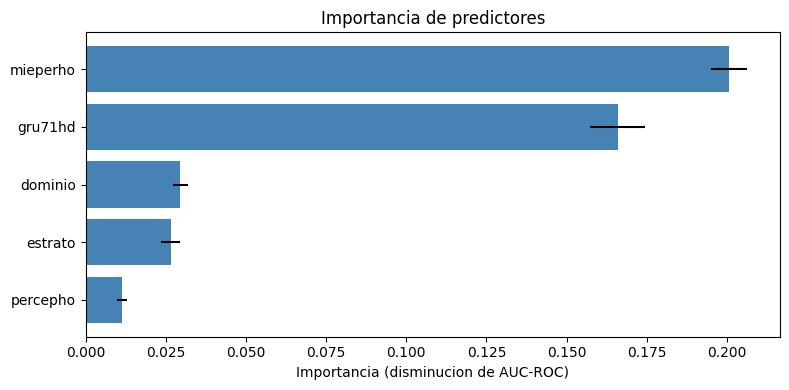

In [13]:
result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=123, n_jobs=-1, scoring="roc_auc"
)

importancias = pd.DataFrame({
    "feature":         features,
    "importance_mean": result.importances_mean,
    "importance_std":  result.importances_std,
}).sort_values("importance_mean", ascending=False)

print("Importancia de variables (disminucion de AUC-ROC):")
print(importancias.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(importancias["feature"], importancias["importance_mean"],
         xerr=importancias["importance_std"], color="steelblue")
plt.xlabel("Importancia (disminucion de AUC-ROC)")
plt.title("Importancia de predictores")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 10. Guardar modelo

In [14]:
joblib.dump(best_model, MODEL_FILE)
print("Modelo guardado en:", MODEL_FILE)
print("Tamanio:", round(MODEL_FILE.stat().st_size / 1024, 1), "KB")

modelo_cargado = joblib.load(MODEL_FILE)
print("Verificacion de carga: OK")
print("Clases del modelo:", modelo_cargado.classes_)

Modelo guardado en: D:\2025\PEU-IENI\CURSO POWER BI\EXAMEN_FINAL\Regresion\modelo_rf_enaho_2024_binario.joblib
Tamanio: 12127.3 KB
Verificacion de carga: OK
Clases del modelo: [0 1]


# 11. Ejemplo de predicción con nuevos datos

In [15]:
nuevo_hogar = pd.DataFrame({
    "mieperho": [4],
    "percepho": [2],
    "dominio":  ["sierra norte"],
    "estrato":  ["de 20 000 a 49 999 habitantes"],
    "gru71hd":  [500.0],
})

prediccion   = modelo_cargado.predict(nuevo_hogar)[0]
probabilidad = modelo_cargado.predict_proba(nuevo_hogar)[0]

etiqueta = "No pobre" if prediccion == 1 else "Pobre"
print("Clase predicha          :", etiqueta, "(clase", str(prediccion) + ")")
print("Prob. Pobre   (clase 0) :", round(probabilidad[0], 4))
print("Prob. No pobre (clase 1):", round(probabilidad[1], 4))

Clase predicha          : Pobre (clase 0)
Prob. Pobre   (clase 0) : 0.7373
Prob. No pobre (clase 1): 0.2627
